In [1]:
import pandas as pd

In [ ]:
df_hourly_gb_2017 = pd.read_csv('data/energy_prices/Energy prices Great Britain 2017.csv')

In [ ]:
df_hourly_gb_2017.head()

,MTU (CET/CEST),Area,Sequence,Day-ahead Price (GBP/MWh),Intraday Period (CET/CEST),Intraday Price (GBP/MWh)
0,01/01/2017 00:00:00 - 01/01/2017 01:00:00,BZN|GB,Without Sequence,51.52,NaN,NaN
1,01/01/2017 01:00:00 - 01/01/2017 02:00:00,BZN|GB,Without Sequence,51.95,NaN,NaN
2,01/01/2017 02:00:00 - 01/01/2017 03:00:00,BZN|GB,Without Sequence,65.00,NaN,NaN
3,01/01/2017 03:00:00 - 01/01/2017 04:00:00,BZN|GB,Without Sequence,51.97,NaN,NaN
4,01/01/2017 04:00:00 - 01/01/2017 05:00:00,BZN|GB,Without Sequence,41.92,NaN,NaN


In [ ]:
df_yearly = pd.read_csv("yearly_report.csv")

In [2]:
df_hourly = pd.read_parquet("hourly_report.parquet", )

In [3]:
df_hourly['spread'] = df_hourly['price_import']-df_hourly['price_export']

In [4]:
df_hourly.columns

Index(['datetime', 'year', 'from_country', 'to_country', 'partner', 'flow_mw',
       'price_export', 'price_import', 'value_eur', 'congestion_rent',
       'capacity_mw', 'utilization_rate', 'spread'],
      dtype='object')

In [5]:
df_hourly.loc[lambda x: x.utilization_rate>1]

,datetime,year,from_country,to_country,partner,flow_mw,price_export,price_import,value_eur,congestion_rent,capacity_mw,utilization_rate,spread
7,2021-01-01 00:00:00,2021,Germany,France,Germany,1236.09,50.8700,50.87,62879.89830,0.0000,1200.0,1.030075,0.00
24,2021-01-01 02:00:00,2021,Belgium,France,Belgium,905.55,44.6800,44.68,40459.97400,0.0000,700.0,1.293643,0.00
142,2021-01-01 11:00:00,2021,Spain,France,Spain,3112.29,37.5500,47.20,116866.48950,30033.5985,3098.0,1.004613,9.65
144,2021-01-01 12:00:00,2021,Belgium,France,Belgium,906.83,50.7800,50.78,46048.82740,0.0000,700.0,1.295471,0.00
228,2021-01-01 19:00:00,2021,Belgium,France,Belgium,781.17,60.3600,60.36,47151.42120,0.0000,700.0,1.115957,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1261779,2025-12-30 16:00:00,2025,France,Great Britain,Great Britain,7128.04,87.1500,NaN,621208.68600,NaN,7056.0,1.010210,NaN
1261791,2025-12-30 17:00:00,2025,France,Great Britain,Great Britain,7102.48,99.5950,NaN,707371.49560,NaN,7056.0,1.006587,NaN
1261899,2025-12-31 02:00:00,2025,France,Great Britain,Great Britain,7080.82,80.2175,NaN,568005.67835,NaN,7056.0,1.003518,NaN
1261995,2025-12-31 10:00:00,2025,France,Great Britain,Great Britain,7072.90,90.1900,NaN,637904.85100,NaN,7056.0,1.002395,NaN


In [6]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def plot_spread_vs_utilization(df, partner_country, start_date, end_date):
    """
    Trace le spread de prix et le taux d'utilisation pour un pays et une période donnés.
    """
    # 1. Filtrer par partenaire et par dates
    mask = (df["partner"] == partner_country) & \
           (df["datetime"] >= start_date) & \
           (df["datetime"] <= end_date)
    
    df_filtered = df[mask].copy()
    
    # 2. Calcul du spread absolu
    if "spread" not in df_filtered.columns:
        df_filtered["spread"] = (df_filtered["price_export"] - df_filtered["price_import"]).abs()
        
    # --- LA CORRECTION EST ICI ---
    # On écrase les doublons d'import/export en gardant la valeur d'utilisation maximale pour chaque heure
    df_plot = (
        df_filtered.groupby("datetime", as_index=False)[["utilization_rate", "spread"]]
        .max()
        .sort_values("datetime")
    )
    # -----------------------------

    # Création du graphique avec double axe Y
    fig = make_subplots(specs=[[{"secondary_y": True}]])

    # Tracé du taux d'utilisation (avec df_plot)
    fig.add_trace(
        go.Scatter(
            x=df_plot["datetime"], 
            y=df_plot["utilization_rate"], 
            name="Taux d'utilisation",
            line=dict(color="royalblue", width=2),
            fill='tozeroy',
            fillcolor='rgba(65, 105, 225, 0.2)'
        ),
        secondary_y=False,
    )

    # Tracé du Spread (avec df_plot)
    fig.add_trace(
        go.Scatter(
            x=df_plot["datetime"], 
            y=df_plot["spread"], 
            name="Spread de prix (€/MWh)",
            line=dict(color="firebrick", width=2)
        ),
        secondary_y=True,
    )

    # Ligne repère de saturation à 100%
    fig.add_hline(y=1, line_dash="dot", line_color="black", secondary_y=False)

    # Mise en forme
    fig.update_layout(
        title=f"Dynamique Spread vs Saturation : France - {partner_country}",
        xaxis_title="Date et Heure",
        hovermode="x unified", 
        template="plotly_white"
    )

    fig.update_yaxes(title_text="<b>Taux d'utilisation</b> (0 à 1)", range=[0, 1.1], secondary_y=False)
    fig.update_yaxes(title_text="<b>Spread</b> (€/MWh)", secondary_y=True)

    return fig

# --- TEST ---
fig = plot_spread_vs_utilization(
    df_hourly, # Assurez-vous d'utiliser votre dataframe chargé
    partner_country="Spain", 
    start_date="2024-01-01", 
    end_date="2024-01-10"
)

fig.show()

In [7]:
import os
import numpy as np
import pandas as pd
zone_map = {
        "FR": "France",
        "BE": "Belgium",
        "CH": "Switzerland",
        "DE-LU": "Germany",
        "DE-AT-LU": "Germany",
        "DE(TransnetBW)": "Germany",
        "DE(Amprion)": "Germany",
        "ES": "Spain",
        "GB": "Great Britain",
        "GB(ElecLink)": "Great Britain",
        "GB(IFA)": "Great Britain",
        "GB(IFA2)": "Great Britain",
        "IT-North": "Italy-North",
        "IT-North-FR": "Italy-North",
        "IT": "Italy-North",
        "LU": "Germany",
}

def load_entsoe_folder(
    folder_path, value_type="total", years=[2015,2016,2017,2018,2019,2020,2021, 2022, 2023, 2024]
):
    """Charge les fichiers ENTSO-E en convertissant dynamiquement l'UTC vers le

    CET/CEST si nécessaire.
    """
    all_df = []
    years = [str(y) for y in years]

    if "zone_map" not in globals():
        raise NameError(
            "Le dictionnaire 'zone_map' doit être défini avant d'appeler la fonction."
        )

    for fname in os.listdir(folder_path):
        if not fname.endswith(".csv") or not any(year in fname for year in years):
            continue

        print("Lecture :", fname)
        path = os.path.join(folder_path, fname)
        df = pd.read_csv(path)

        # Nettoyage des espaces dans les noms de colonnes
        df.columns = df.columns.str.strip()

        # 1. Détection adaptative de la colonne MTU et de son fuseau
        mtu_col = None
        for col in df.columns:
            if "MTU" in col:
                mtu_col = col
                break

        if mtu_col is None:
            print(f"⚠️ MTU introuvable dans {fname}, fichier ignoré.")
            continue

        # Extraction de la date de début de l'intervalle
        start_dates = df[mtu_col].astype(str).str.split(" - ").str[0]
        dt_series = pd.to_datetime(start_dates, dayfirst=True, errors="coerce")

        # --- GESTION DYNAMIQUE DU FUSEAU HORAIRE ---
        if "UTC" in mtu_col:
            # Si le fichier est en UTC, on le localise en UTC puis on convertit en heure de Paris
            dt_series = (
                dt_series.dt.tz_localize("UTC")
                .dt.tz_convert("Europe/Paris")
                .dt.tz_localize(None)
            )
            print(f"   -> Conversion UTC vers CET/CEST appliquée pour {fname}")
        else:
            # Si c'est déjà du CET/CEST (ou pas spécifié), on garde l'heure telle quelle
            print(f"   -> Conservation de l'heure native (CET/CEST) pour {fname}")

        df["datetime"] = dt_series
        # -------------------------------------------

        # 2. Sélection de la colonne de valeur
        if value_type == "day_ahead":
            value_col = "Day Ahead - Value (MW)"
            col_name = "day_ahead_mw"
        elif value_type == "total":
            value_col = "Total - Value (MW)"
            col_name = "total_mw"
        else:
            raise ValueError(
                "value_type invalide. Choisissez 'day_ahead' ou 'total'."
            )

        if value_col not in df.columns:
            print(f"⚠️ Colonne '{value_col}' absente de {fname}, fichier ignoré.")
            continue

        df[value_col] = pd.to_numeric(df[value_col], errors="coerce")

        # 3. Nettoyage et mapping des zones
        df["from_country"] = (
            df["Out Area"]
            .str.split("|", n=1, regex=False)
            .str[-1]
            .str.strip()
            .map(zone_map)
        )
        df["to_country"] = (
            df["In Area"]
            .str.split("|", n=1, regex=False)
            .str[-1]
            .str.strip()
            .map(zone_map)
        )

        # Filtrer pour la France
        df = df[(df["from_country"] == "France") | (df["to_country"] == "France")].copy()

        if df.empty:
            continue

        # Pays partenaire
        df["partner"] = np.where(
            df["from_country"] == "France", df["to_country"], df["from_country"]
        )

        # 4. Préparation des colonnes finales
        df[col_name] = df[value_col]
        df["year"] = df["datetime"].dt.year

        # 5. Agrégation pour éliminer les doublons
        df = (
            df.groupby(
                ["datetime", "year", "from_country", "to_country", "partner"],
                as_index=False,
            )[col_name]
            .sum()
        )

        all_df.append(
            df[
                [
                    "datetime",
                    "year",
                    "from_country",
                    "to_country",
                    "partner",
                    col_name,
                ]
            ]
        )

    if not all_df:
        raise ValueError("Aucun fichier valide n'a pu être traité.")

    return pd.concat(all_df, ignore_index=True)

In [8]:
truc = load_entsoe_folder('data/flows_com')

Lecture : Scheduled Commercial Exchange 2018.csv
   -> Conversion UTC vers CET/CEST appliquée pour Scheduled Commercial Exchange 2018.csv
Lecture : Scheduled Commercial Exchange 2023.csv
   -> Conversion UTC vers CET/CEST appliquée pour Scheduled Commercial Exchange 2023.csv
Lecture : Scheduled Commercial Exchange 2024.csv
   -> Conversion UTC vers CET/CEST appliquée pour Scheduled Commercial Exchange 2024.csv
Lecture : Scheduled Commercial Exchange 2021.csv
   -> Conversion UTC vers CET/CEST appliquée pour Scheduled Commercial Exchange 2021.csv
Lecture : Scheduled Commercial Exchange 2016.csv
   -> Conversion UTC vers CET/CEST appliquée pour Scheduled Commercial Exchange 2016.csv
Lecture : Scheduled Commercial Exchange 2022.csv
   -> Conservation de l'heure native (CET/CEST) pour Scheduled Commercial Exchange 2022.csv
Lecture : Scheduled Commercial Exchange 2019.csv
   -> Conversion UTC vers CET/CEST appliquée pour Scheduled Commercial Exchange 2019.csv
Lecture : Scheduled Commercial 

In [9]:
truc

,datetime,year,from_country,to_country,partner,total_mw
0,2018-01-01 01:00:00,2018.0,Belgium,France,Belgium,1099.0
1,2018-01-01 01:00:00,2018.0,France,Belgium,Belgium,143.7
2,2018-01-01 01:00:00,2018.0,France,Germany,Germany,0.0
3,2018-01-01 01:00:00,2018.0,France,Great Britain,Great Britain,2000.0
4,2018-01-01 01:00:00,2018.0,France,Italy-North,Italy-North,1285.0
...,...,...,...,...,...,...
753551,2018-01-01 00:00:00,2018.0,Germany,France,Germany,6395.7
753552,2018-01-01 00:00:00,2018.0,Great Britain,France,Great Britain,296.0
753553,2018-01-01 00:00:00,2018.0,Italy-North,France,Italy-North,0.0
753554,2018-01-01 00:00:00,2018.0,Spain,France,Spain,550.0


In [10]:
df_hourly = df_hourly.merge(truc, on = ['datetime', 'year', 'from_country', 'to_country', 'partner'], how='left')

In [14]:
truc.sort_values(by='datetime')   

,datetime,year,from_country,to_country,partner,total_mw
648459,2017-01-01 01:00:00,2017.0,Switzerland,France,Switzerland,869.40
648458,2017-01-01 01:00:00,2017.0,Spain,France,Spain,20.00
648457,2017-01-01 01:00:00,2017.0,Italy-North,France,Italy-North,2410.00
648456,2017-01-01 01:00:00,2017.0,Great Britain,France,Great Britain,0.00
648455,2017-01-01 01:00:00,2017.0,Germany,France,Germany,4235.30
...,...,...,...,...,...,...
315603,2025-01-01 00:00:00,2025.0,France,Great Britain,Great Britain,640.00
315602,2025-01-01 00:00:00,2025.0,France,Germany,Germany,0.00
315601,2025-01-01 00:00:00,2025.0,France,Belgium,Belgium,8.85
315606,2025-01-01 00:00:00,2025.0,France,Switzerland,Switzerland,3200.00


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurer le style des graphiques
sns.set_theme(style="whitegrid")


def plot_somme_flux_pays(df, pays_partenaire):
    """Filtre le dataframe pour un pays partenaire et trace la somme totale des

    flux (Import + Export).
    """
    # 1. Filtrer les données pour le pays choisi
    df_pays = df[df["partner"] == pays_partenaire].copy()

    if df_pays.empty:
        print(f"Aucune donnée trouvée pour le pays : {pays_partenaire}")
        return

    # 2. Sommer les flux (In et Out) pour chaque heure (datetime)
    # Utile si le DataFrame d'origine contient une ligne pour l'import et une pour l'export à la même heure
    df_grouped = (
        df_pays.groupby("datetime", as_index=False)["total_mw"].sum()
    )

    # 3. Trier par ordre chronologique
    df_grouped = df_grouped.sort_values("datetime")

    # 4. Création du graphique
    plt.figure(figsize=(14, 6))

    # Tracer la courbe du flux total
    sns.lineplot(
        data=df_grouped,
        x="datetime",
        y="total_mw",
        label=f"Volume total des flux (France <-> {pays_partenaire})",
        color="indigo",
        linewidth=1.5,
    )

    # Remplir sous la courbe pour une meilleure visualisation du volume
    plt.fill_between(
        df_grouped["datetime"],
        df_grouped["total_mw"],
        color="indigo",
        alpha=0.1,
    )

    # Personnalisation des axes et titres
    plt.title(
        f"Volume total des échanges d'électricité : France - {pays_partenaire} (Somme Import + Export)",
        fontsize=14,
        fontweight="bold",
    )
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Flux Total (MW)", fontsize=12)
    plt.legend(loc="upper left")

    # Ajustement automatique des espaces
    plt.tight_layout()
    plt.show()


# --- COMMENT L'UTILISER ---
# plot_somme_flux_pays(truc, "Espagne")

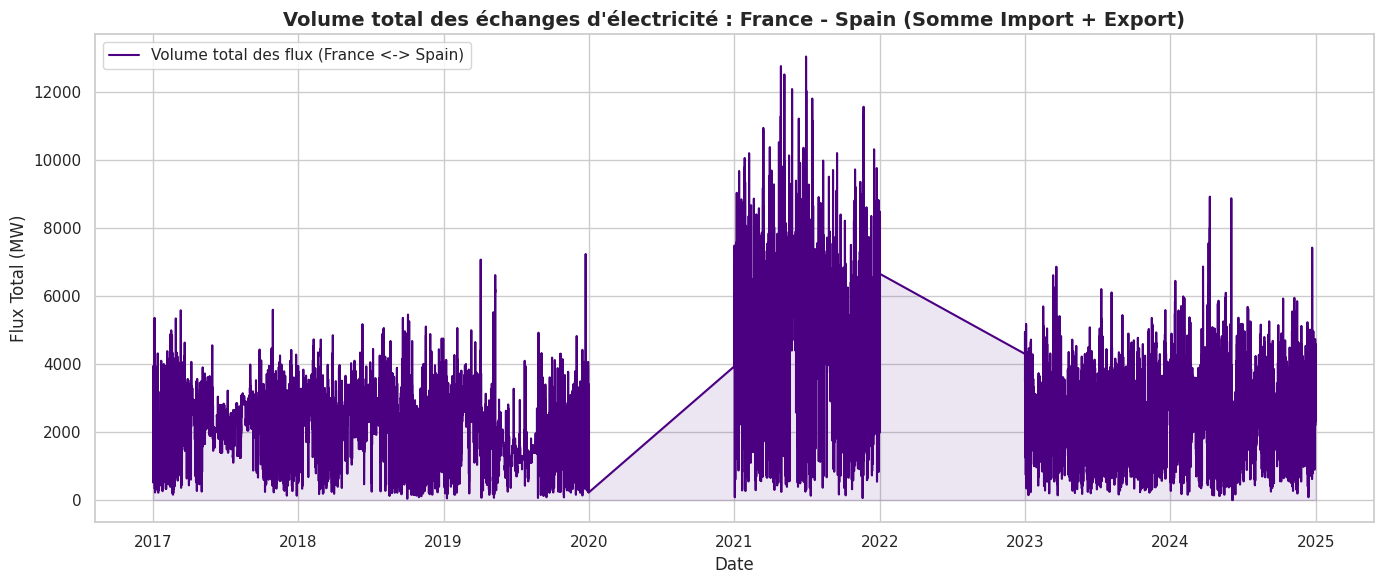

In [17]:
plot_somme_flux_pays(truc, 'Spain')

In [19]:
truc.loc[(truc.year==2022)&(truc.partner=='Spain')]

,datetime,year,from_country,to_country,partner,total_mw
420713,2022-01-01,2022.0,France,Spain,Spain,3330.0
420718,2022-01-01,2022.0,Spain,France,Spain,0.0
525821,2022-01-01,2022.0,France,Spain,Spain,3330.0
525826,2022-01-01,2022.0,Spain,France,Spain,0.0


In [20]:
pd.read_csv('data/flows_com/Scheduled Commercial Exchange 2022.csv')

,MTU (CET/CEST),Out Area,In Area,Day Ahead - Value (MW),Day Ahead - Export/Import,Total - Value (MW),Total - Export/Import
0,01/01/2022 00:00 - 01/01/2022 01:00,BZN|DE-LU,BZN|AT,930.00,NaN,879.10,NaN
1,01/01/2022 00:00 - 01/01/2022 01:00,BZN|AT,BZN|DE-LU,0.00,NaN,0.00,NaN
2,01/01/2022 00:00 - 01/01/2022 01:00,BZN|DE-LU,BZN|BE,945.90,NaN,1061.25,NaN
3,01/01/2022 00:00 - 01/01/2022 01:00,BZN|BE,BZN|DE-LU,0.00,NaN,516.55,NaN
4,01/01/2022 00:00 - 01/01/2022 01:00,BZN|DE-LU,BZN|CH,800.00,NaN,755.73,NaN
...,...,...,...,...,...,...,...
201475,31/12/2022 23:00 - 01/01/2023 00:00,BZN|NO2,BZN|DE-LU,0.00,NaN,0.00,NaN
201476,31/12/2022 23:00 - 01/01/2023 00:00,BZN|DE-LU,BZN|PL,498.20,NaN,498.20,NaN
201477,31/12/2022 23:00 - 01/01/2023 00:00,BZN|PL,BZN|DE-LU,0.00,NaN,20.30,NaN
201478,31/12/2022 23:00 - 01/01/2023 00:00,BZN|DE-LU,BZN|SE4,316.00,NaN,316.00,NaN
